## Churn Analysis Project: To understand key factors that lead to churn and what preventative measures and retention strategies can be implemented to increase retention rates and retain maximum revenue.

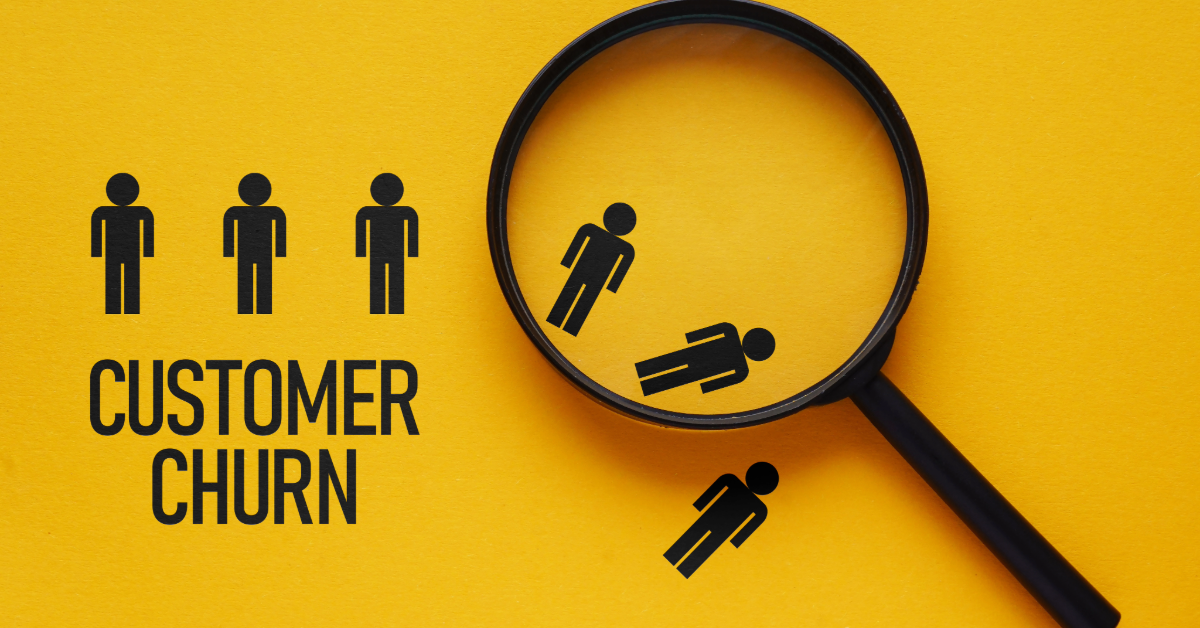


## INTRODUCTION ##

**Customer churn** refers to when customers stop using a company’s product or service, or end their subscription within a given time period. It is a key business metric because it affects revenue, growth, and customer retention.

In this churn dataset, we are looking at data covering a period of 5 years. The churn label shows whether a customer has left or stayed. A churned customer is someone who has discontinued their relationship with the company, while a non-churned customer continues to use the service.

Analyzing churn is important because it helps businesses understand the patterns and factors that lead customers to leave. By identifying these signals, companies can improve retention strategies, increase customer satisfaction, and reduce loss over time. Churn analysis can also support predictive modeling, allowing businesses to spot at-risk customers early and take action before they leave.


**Definition Of Some Columns**

**Tenure** : Duration in months for which a customer has been using the company's products or services

**Usage Frequency** : Number of times that the customer has used the company’s services in the last month

**Support Calls** : Number of calls that the customer has made to the customer support in the last month

**Payment Delay** : Number of days that the customer has delayed their payment in the last month

**Subscription Type** : Type of subscription the customer has choosen

**Contract Length** : Duration of the contract that the customer has signed with the company

**Total Spend** : Total amount of money the customer has spent on the company's products or services

**Last Interaction** : Last Interaction: Number of days since the last interaction that the customer had with the company

**Churn** : Binary label indicating whether a customer has churned (1) or not (0)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Import both datasets**
Dataset source:https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset?select=customer_churn_dataset-training-master.csv
2 Datasets testing and training 

In [2]:
train = pd.read_csv("/Users/estelle90/Downloads/Customer Churn Dataset/customer_churn_dataset-training-master.csv")
test = pd.read_csv("/Users/estelle90/Downloads/Customer Churn Dataset/customer_churn_dataset-testing-master.csv")

In [3]:
print(f"Train shape : {train.shape}")
print(f"Test shape : {test.shape}")

Train shape : (440833, 12)
Test shape : (64374, 12)


As the datasets both contain the same number of columns and variables I will combine them to have a complete df for a more accurate analysis 

In [4]:
customer_churn = pd.concat([train, test], axis=0, ignore_index=True)
customer_churn

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


## Exploratory Data Analysis

In [5]:
customer_churn.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [6]:
customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [7]:
customer_churn.shape

(505207, 12)

In [8]:
customer_churn.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [9]:
rows_with_nan = customer_churn[customer_churn.isna().any(axis=1)]

rows_with_nan

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now I can be sure that the NAN values are isolated to 1 row, removing it will not affect my analysis

In [10]:
customer_churn.dropna(inplace =True)

customer_churn.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

'Customer_ID' holds no value and is irrevevant to the analysis, proceed to drop column

In [11]:
customer_churn = customer_churn.drop(columns=['CustomerID'])
customer_churn


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
505202,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


## Descriptive Statistics

I am examining the distribution of numerical features to identify potential outliers and understand the average profile of our customers.


In [12]:
customer_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,505206.0,39.704172,12.670577,18.0,29.0,40.0,49.0,65.0
Tenure,505206.0,31.350435,17.237482,1.0,16.0,32.0,46.0,60.0
Usage Frequency,505206.0,15.714825,8.619323,1.0,8.0,16.0,23.0,30.0
Support Calls,505206.0,3.833317,3.133603,0.0,1.0,3.0,6.0,10.0
Payment Delay,505206.0,13.496843,8.451187,0.0,6.0,13.0,20.0,30.0
Total Spend,505206.0,620.072766,245.319256,100.0,446.0,648.9,824.0,1000.0
Last Interaction,505206.0,14.610581,8.608286,1.0,7.0,14.0,22.0,30.0
Churn,505206.0,0.555203,0.496944,0.0,0.0,1.0,1.0,1.0


Initial inspection of the descriptive statistics suggested a clean dataset. While 'Total Spend' shows a slight left-skew (Mean < Median), the proximity of the 75th percentile to the Max across all behavioral columns suggests that 'extreme' behaviors are within reasonable operational limits

### Univariate Analysis

Analyse target variable to determine balance

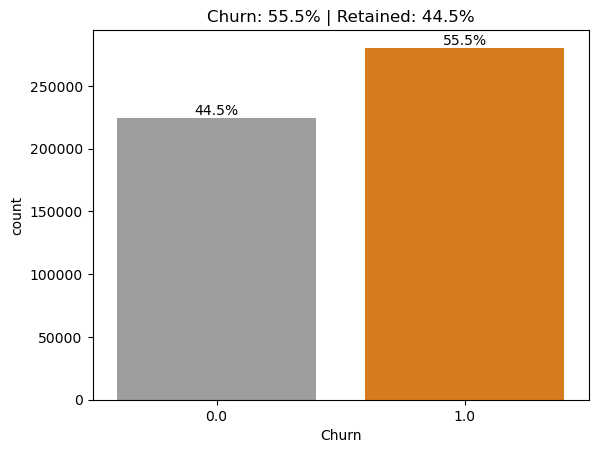

In [13]:
bar = sns.countplot(data=customer_churn, x='Churn', palette=['#9e9e9e', '#F57C00'])
total = len(customer_churn)

churn_pct = (customer_churn['Churn'].value_counts(normalize=True) * 100)[1]

# Auto-add % labels (modern way)
for container in bar.containers:
    bar.bar_label(container, fmt=lambda x: f'{x/total*100:.1f}%')

plt.title(f'Churn: {churn_pct:.1f}% | Retained: {100-churn_pct:.1f}%')
plt.show()


### Target Variable Analysis: Churn Distribution

The dataset contains **505,206** records with a moderately imbalanced distribution:

* **Churned (1.0):** 55.5%
* **Retained (0.0):** 44.5%

Continue univariate analysis for numerical data.

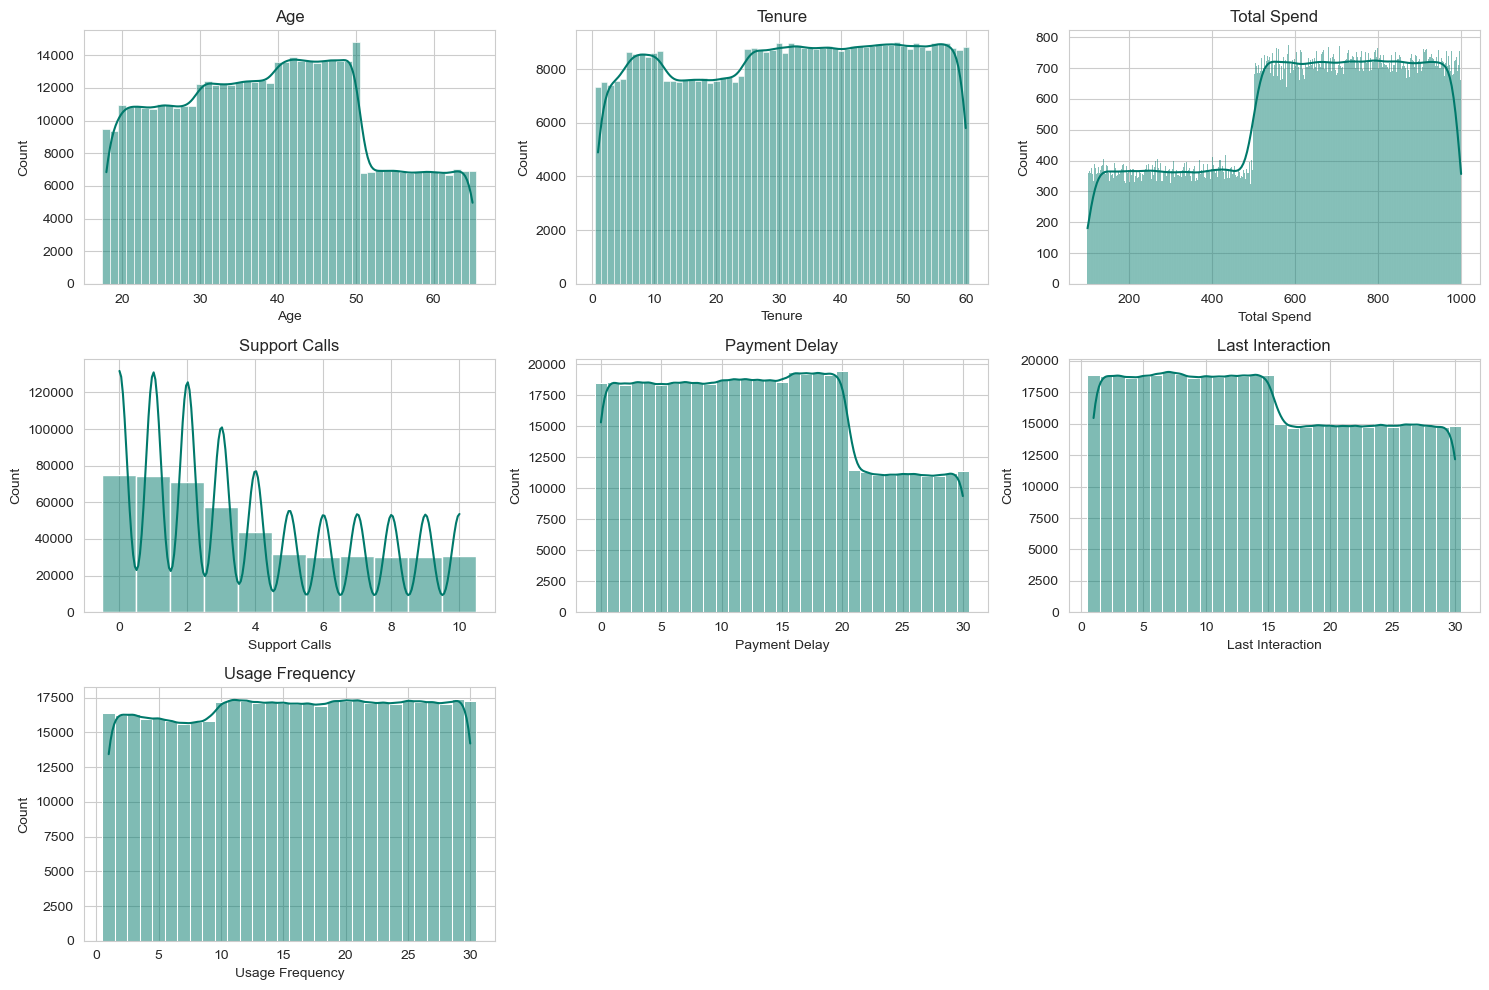

In [14]:
chart = customer_churn
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(['Age', 'Tenure', 'Total Spend', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Usage Frequency']):
    r, c = divmod(i, 3)
    sns.histplot(data=chart, x=col, kde=True, ax=axes[r,c], color='#00796B', discrete=True)
    axes[r,c].set_title(col)

axes[2,1].set_visible(False)  
axes[2,2].set_visible(False) 

plt.tight_layout()
plt.show()

## Univariate Analysis Insights

**Demographics:** The customer base is younger-skewed, suggesting a strong product-market fit with Gen Z/Millennials.

**Revenue Health:** Total Spend is Left-Skewed, indicating that the majority of our users are high-value, premium subscribers.

**Behavioral Baselines:** Both Support Calls and Payment Delays are Right-Skewed, showing that while the "average" customer has few issues, there is a small, high-friction segment that likely drives our churn numbers.

**Check for any Outliers** 


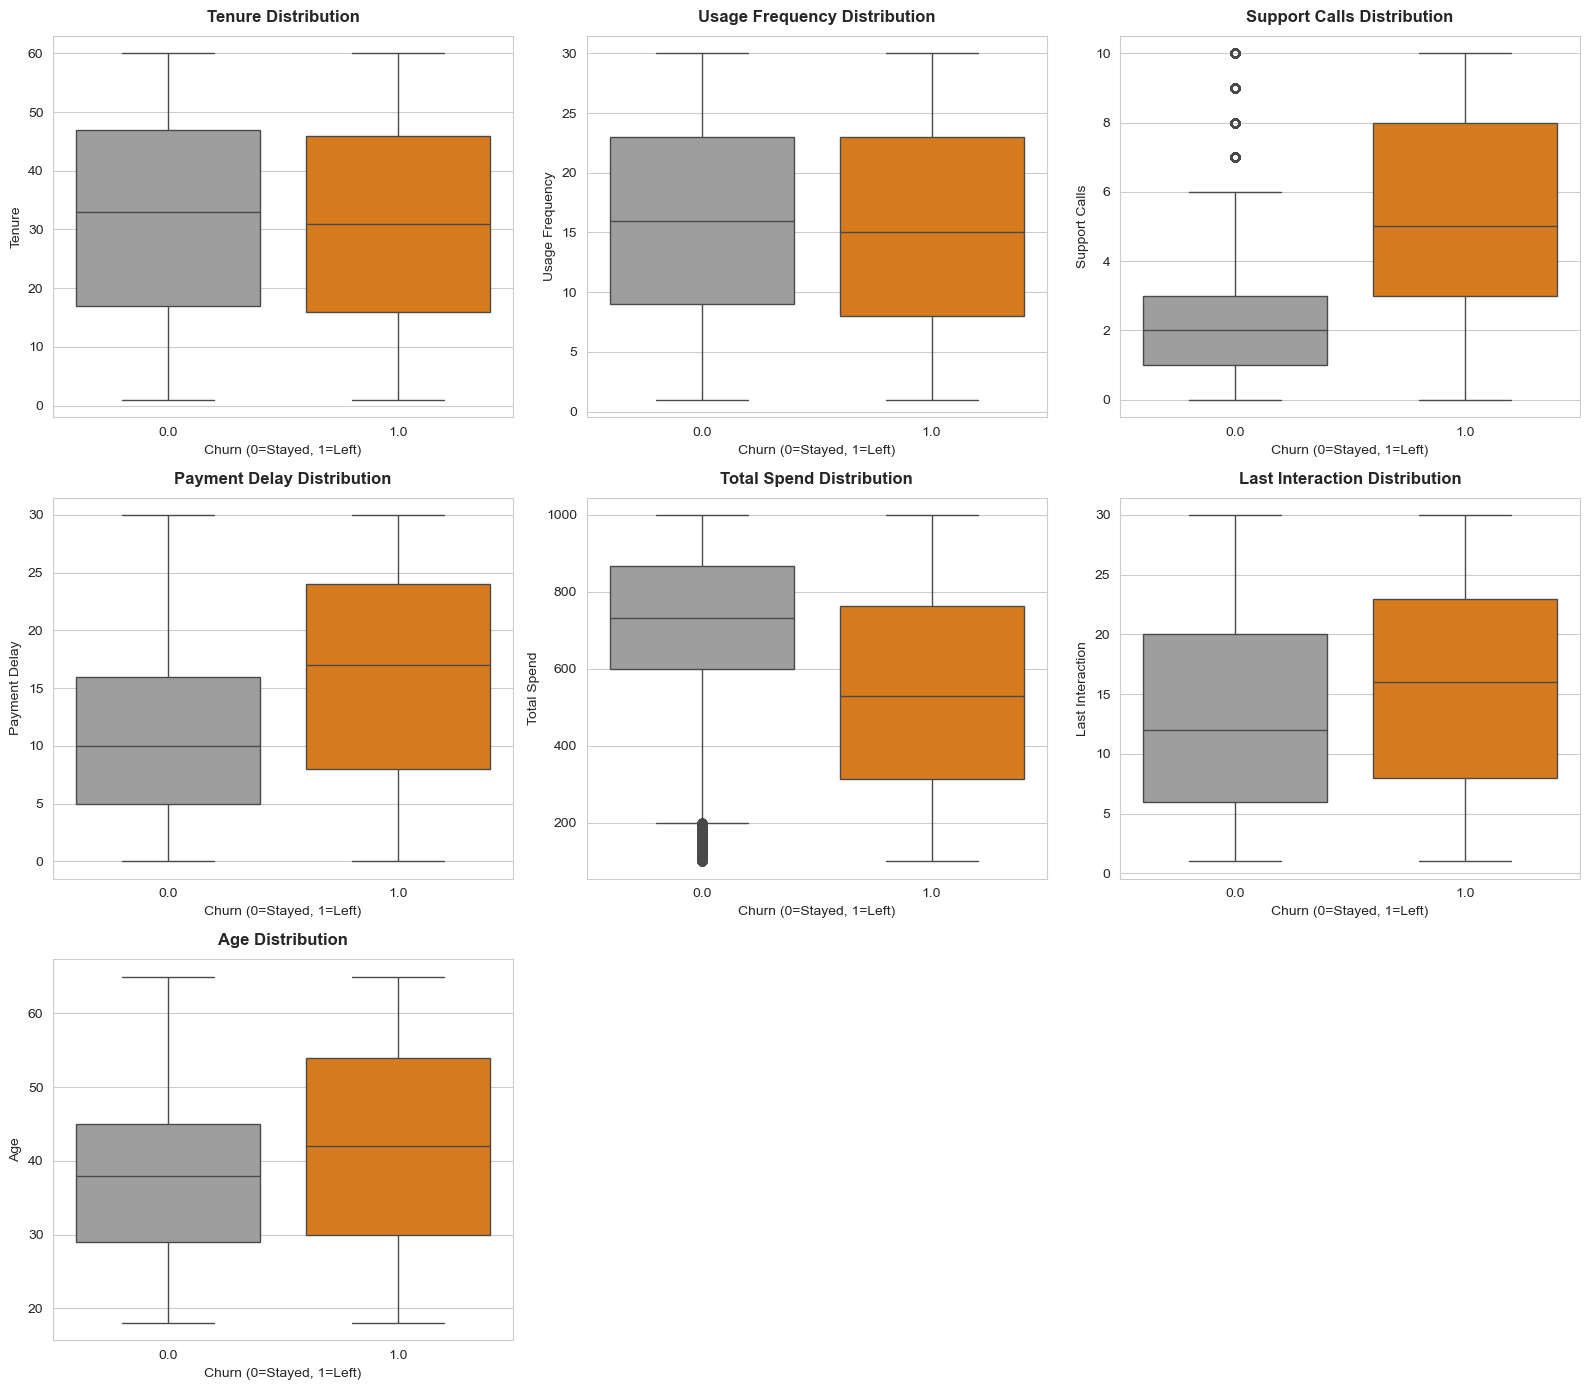

In [15]:
# Churned = 1 Stayed = 0

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
cols = ['Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 
        'Total Spend', 'Last Interaction', 'Age']

axes_flat = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=customer_churn, x='Churn', y=col, ax=axes_flat[i], palette=['#9e9e9e', '#F57C00'])
    axes_flat[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold', pad=10)
    axes_flat[i].set_xlabel('Churn (0=Stayed, 1=Left)')

for j in range(len(cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## Boxplots observation when comparing each factor against the target variable 'Churn'

**Payment Delay by Churn**
There is a clear positive correlation between payment delays and attrition. The median payment delay for churned users is significantly higher, suggesting that payment friction is a leading indicator of customer dissatisfaction.

**Total Spend by Churn** 
Higher total spend is associated with increased customer retention. However, the presence of high-spend outliers in the churn group indicates that even 'VIP' customers are at risk if other service factors (like support) are not met.
 
**Support Calls by Churn** 
Support call volume is the strongest behavioral predictor of churn. While most retained customers have 0-3 calls, the churned population is heavily concentrated in the 6+ call range. The outliers in the 'Stayed' group represent a critical segment for proactive retention outreach.

**Age by Churn**
Retention is highest among the 25–45 age demographic. In contrast, the 55+ segment shows a disproportionately high churn rate (90%+), suggesting the current service model may not be effectively meeting the needs of older users

In [16]:
# What percent of Ouliers are there in each variable?

num = customer_churn.select_dtypes(include='number')

Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (num < lower) | (num > upper)

outlier_pct = outliers.mean() * 100
print(outlier_pct)

Age                 0.0
Tenure              0.0
Usage Frequency     0.0
Support Calls       0.0
Payment Delay       0.0
Total Spend         0.0
Last Interaction    0.0
Churn               0.0
dtype: float64


**Statistical Observation: Local vs. Global Outliers**

While no global outliers exist in the dataset (all values fall within $1.5 \times IQR$ of the total population), the boxplots reveal local outliers within the 'Stayed' group. This indicates that even a moderate increase in support calls (6+) is 'abnormal' behavior for a loyal customer and serves as an early warning sign of potential churn.

What is the timespan of the dataset?

In [18]:
print(f"Dataset time frame: {customer_churn['Tenure'].min()} to {customer_churn['Tenure'].max()} months")
print(f"~{customer_churn['Tenure'].max()/12:.1f} years of customer history")


Dataset time frame: 1.0 to 60.0 months
~5.0 years of customer history


## 🔍 Correlation Analysis

Analyse correlations between numeric features and target variable Churn to identify key churn drivers.

Decision: Skipped categorical encoding (get_dummies()) to maintain a clean, interpretable 8x8 heatmap focused on:

Feature-to-feature relationships
Direct churn predictors

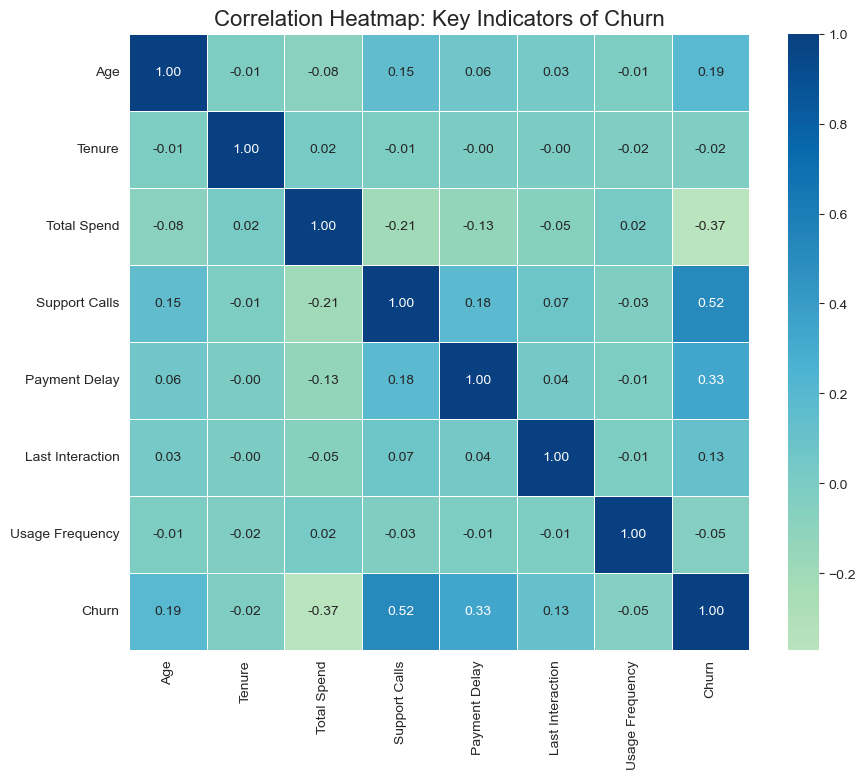

In [110]:
numeric_cols = ['Age', 'Tenure', 'Total Spend', 'Support Calls', 
                'Payment Delay', 'Last Interaction', 'Usage Frequency', 'Churn']

plt.figure(figsize=(10, 8))
corr_matrix = customer_churn[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='GnBu', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Key Indicators of Churn', fontsize=16)
plt.show()

## 📊 Key Correlation Insights

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| **Support Calls** | **+Strong** | ❌ **Highest churn risk** - Frequent support contacts signal dissatisfaction |
| **Payment Delay** | **+Moderate** | ⚠️ **Billing issues** drive churn - Late payments = red flag |
| **Total Spend** | **-Moderate** | ✅ **Top spenders stay loyal** - Higher spend = stronger retention |

### 🎯 Business Takeaways:
1. **Support Calls** = **#1 early warning** → Proactive outreach needed
2. **Payment Delays** = **Billing friction** → Automate reminders, flexible plans
3. **High Spenders** = **VIP retention** → Loyalty programs, premium support


Three primary factors appear to influence churn risk. To assess their impact, the mean values for each factor are compared between customers who churned (Churn = 1) and those who remained (Churn = 0).

In [95]:
factors = ['Support Calls', 'Payment Delay', 'Total Spend']

stats = []
for factor in factors:
    summary = customer_churn.groupby('Churn')[factor].agg(['mean'])
    for churn, row in summary.iterrows():
        label = "Churned" if churn == 1 else "Retained"
        stats.append({
            "Status": label,
            "Metric": factor,
            "Mean": f"{row['mean']:.1f}"
        })

stats_df = pd.DataFrame(stats)
stats_pivot = stats_df.pivot_table(
    index="Metric",
    columns="Status",
    values=["Mean"],
    aggfunc="first"
)
stats_pivot.columns = [f"{col[0]} ({col[1]})" for col in stats_pivot.columns]

print("\nKey Churn Drivers Summary:")
print(stats_pivot.to_string())


Key Churn Drivers Summary:
              Mean (Churned) Mean (Retained)
Metric                                      
Payment Delay           16.0            10.4
Support Calls            5.3             2.0
Total Spend            538.9           721.4


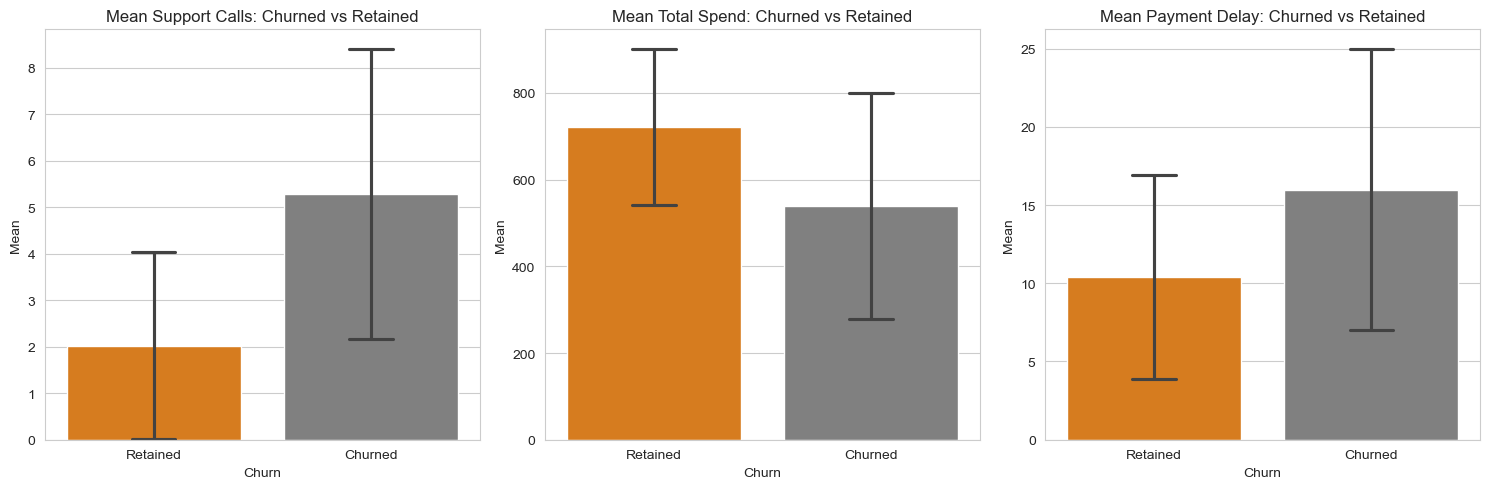

In [96]:
features = ['Support Calls', 'Total Spend', 'Payment Delay']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
    sns.barplot(data=customer_churn, x='Churn', y=feature, 
                errorbar='sd', palette=['#F57C00', 'grey'], 
                capsize=0.2, ax=axes[i])
    axes[i].set_title(f'Mean {feature}: Churned vs Retained')
    axes[i].set_ylabel('Mean')
    axes[i].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

### Churn drivers by metric (mean values)

| Metric          | Churned (mean) | Retained (mean) | 
|-----------------|----------------|-----------------|
| Support Calls   | 5              | 2              | 
| Payment Delay   | 16             | 10             | 
| Total Spend     | 539            | 721            | 


- Retained customers have a **mean total spend** of €721 vs €539 for churned customers, a difference of about **30%**.

- Churned accounts have a **mean number of support calls** roughly twice that of retained accounts.

- Retained accounts have a **mean payment delay** of 10 days, while churned accounts show a delay of 15 days. 


 ## What other factors are associated with churn?

Are specific age groups more likely to churn?

Does churn differ by gender?

Do subscription type and contract length appear to be associated with churn?

In [27]:
customer_churn['Age'].agg(['max', 'min'])

max    65.0
min    18.0
Name: Age, dtype: float64

In [42]:
bins = [18, 25, 35, 45, 55, 66]

labels = ['18-24', '25-34', '35-44', '45-54', '55-66']

customer_churn['Age_Group'] = pd.cut(customer_churn['Age'],
                                    bins=bins,
                                    labels=labels,
                                    right=False)

print(customer_churn[['Age', 'Age_Group']].head())
customer_churn.groupby('Age_Group')['Churn'].mean() * 100


    Age Age_Group
0  30.0     25-34
1  65.0     55-66
2  55.0     55-66
3  58.0     55-66
4  23.0     18-24


Age_Group
18-24    55.360053
25-34    49.259016
35-44    43.459417
45-54    52.693836
55-66    90.227336
Name: Churn, dtype: float64

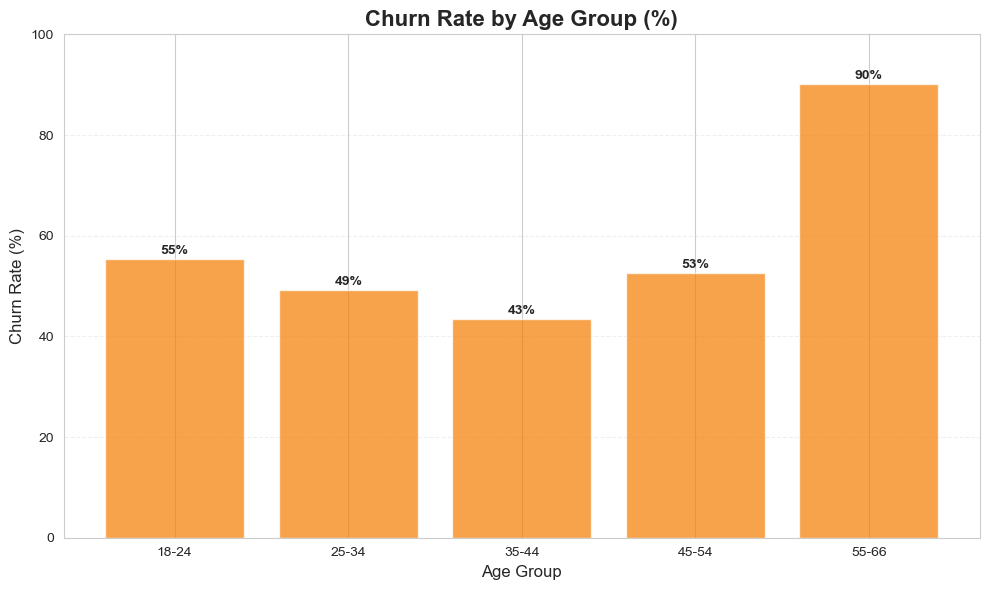

In [54]:
data = {
    'Age_Group': ['18-24', '25-34', '35-44', '45-54', '55-66'],
    'Churn_Rate': [55.36, 49.26, 43.46, 52.69, 90.22]
}
df = pd.DataFrame(data)

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(df['Age_Group'], df['Churn_Rate'], color='#F57C00', alpha=0.7)

# Customize
plt.title('Churn Rate by Age Group (%)', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 100)

# Add value labels on top of bars
for i, v in enumerate(df['Churn_Rate']):
    plt.text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')
    
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Churn by age group**

Across five age segments, four show very high churn rates in the 40–50% range, indicating that churn is widespread across most age groups.
The most concerning segment is customers aged 55–64, with a churn rate of around 90%, making them by far the highest‑risk group in the portfolio.


In [30]:
churn_by_age_gender = customer_churn.groupby(['Age_Group', 'Gender'])['Churn'].mean() * 100
print(churn_by_age_gender)


Age_Group  Gender
18-24      Female    65.163507
           Male      47.456286
25-34      Female    59.371726
           Male      41.414529
35-44      Female    53.821904
           Male      35.850362
45-54      Female    62.428784
           Male      45.093394
55-64      Female    91.152567
           Male      89.267447
Name: Churn, dtype: float64


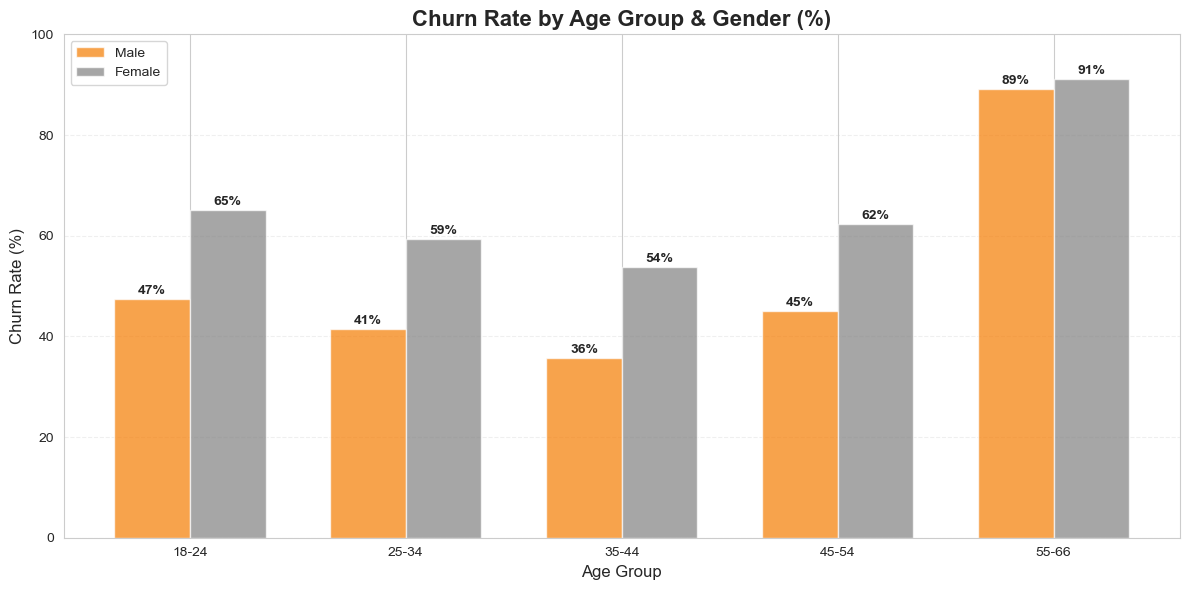

In [97]:
data = {
    'Age_Group': ['18-24', '25-34', '35-44', '45-54', '55-66'] * 2,
    'Gender': ['Male']*5 + ['Female']*5,
    'Churn_Rate': [47.4, 41.4, 35.8, 45.0, 89.2,    
                   65.1, 59.3, 53.8, 62.4, 91.1]    
}
df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
width = 0.35
x = np.arange(len(df['Age_Group'].unique()[:5]))  

plt.bar(x - width/2, df[df['Gender']=='Male']['Churn_Rate'].values[:5], 
        width, label='Male', color='#F57C00', alpha=0.7)
plt.bar(x + width/2, df[df['Gender']=='Female']['Churn_Rate'].values[:5], 
        width, label='Female', color='grey', alpha=0.7)


plt.title('Churn Rate by Age Group & Gender (%)', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(x, ['18-24', '25-34', '35-44', '45-54', '55-66'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, rate in enumerate(df[df['Gender']=='Male']['Churn_Rate'].values[:5]):
    plt.text(i - width/2, rate + 1, f'{rate:.0f}%', ha='center', fontweight='bold')
for i, rate in enumerate(df[df['Gender']=='Female']['Churn_Rate'].values[:5]):
    plt.text(i + width/2, rate + 1, f'{rate:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Churn is high across all age groups, but it is consistently higher for females than males.

The 55–66 age group has the highest churn rate for both genders, at 89% for males and 91% for females.

This suggests that older customers are the most likely to churn, and gender differences may also play a role.

In [32]:
variables = ['Contract Length', 'Subscription Type', 'Gender']

for var in variables:
    summary = customer_churn.groupby(var)['Churn'].agg(['count', 'mean']).round(2)
    summary.columns = ['Total_Customers', 'Churn_Rate']
    summary['Churn_Pct'] = summary['Churn_Rate'] * 100
    print(summary)
    print()

                 Total_Customers  Churn_Rate  Churn_Pct
Contract Length                                        
Annual                    198608        0.46       46.0
Monthly                   109234        0.90       90.0
Quarterly                 197364        0.46       46.0

                   Total_Customers  Churn_Rate  Churn_Pct
Subscription Type                                        
Basic                       164477        0.57       57.0
Premium                     170099        0.55       55.0
Standard                    170630        0.55       55.0

        Total_Customers  Churn_Rate  Churn_Pct
Gender                                        
Female           224933        0.65       65.0
Male             280273        0.48       48.0



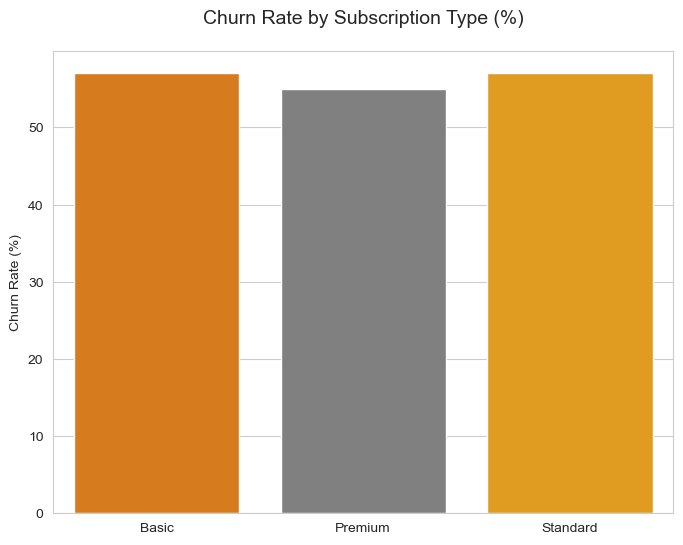

In [33]:
labels = ['Basic', 'Premium', 'Standard']
sizes = [57, 55, 57]
colors = ['#F57C00', 'grey', 'orange']

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=sizes, palette=colors)
plt.title('Churn Rate by Subscription Type (%)', fontsize=14, pad=20)
plt.ylabel('Churn Rate (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.show()

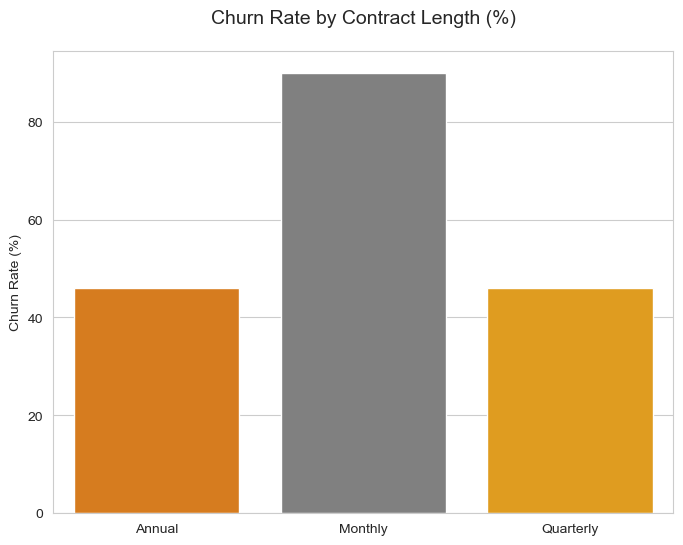

In [34]:
labels = ['Annual', 'Monthly', 'Quarterly']
sizes = [46, 90, 46]
colors = ['#F57C00', 'grey', 'orange']

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=sizes, palette=colors)
plt.title('Churn Rate by Contract Length (%)', fontsize=14, pad=20)
plt.ylabel('Churn Rate (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.show()

Customers on monthly subscriptions have the highest churn rate at 90%, while annual and quarterly subscribers have a much lower churn rate at 46%.

Subscription type shows little variation in churn: Premium and Standard are both 55%, and Basic is 57%.

Overall, contract length appears to be a stronger churn signal than subscription type.


## Conclusion 

The analysis suggests several factors are associated with churn. Higher support call volumes appear to be one of the strongest churn signals, indicating that these customers may need earlier intervention and more targeted support to improve retention and protect revenue. Customers who remain with the business also show higher total spend, reinforcing the value of prioritising retention efforts for higher-value accounts.

Payment delay appears to have a moderate relationship with churn, suggesting that improving billing follow-up and reducing late payments could support better retention. Age is another important factor, with the 55–64 group showing the highest churn rate and representing a major retention risk. This segment may benefit from more tailored support, loyalty initiatives, and exit feedback analysis to better understand the underlying drivers of churn.

Churn also differs by gender, with female customers showing consistently higher churn rates across age groups. In addition, contract length is a particularly strong predictor, as monthly subscribers churn at a much higher rate than annual or quarterly subscribers. Overall, the results suggest that contract length, support usage, age, and payment behaviour are stronger indicators of churn than subscription type alone.



**Strong business actions**

- Prioritise customers with high support contact for proactive outreach and issue resolution.

- Focus retention efforts on monthly subscribers, since they churn far more than annual or quarterly customers.

- Review the 55–66 age segment separately to understand whether product complexity, support needs, or onboarding gaps are driving churn.

- Test retention campaigns for annual upgrades, especially among engaged monthly customers, since conversion to longer-term plans is a common churn-reduction strategy.

- Investigate whether better onboarding, faster issue resolution, or billing follow-up could reduce risk in the high-churn groups.

